In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,text,clean_text,style,tone
0,You are really batting a thousand today with a...,you be really bat a thousand today with all th...,informal,sarcastic
1,We were fascinated by the researchers' bold ch...,we be fascinate by the researcher ' bold choic...,academic,sarcastic
2,I just love it when the server crashes right b...,i just love it when the server crash right bef...,informal,sarcastic
3,The meeting with the marketing department is s...,the meeting with the marketing department be s...,business,neutral
4,Your team's persistent failure to consistently...,your team 's persistent failure to consistentl...,business,aggressive


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        500 non-null    str  
 1   clean_text  500 non-null    str  
 2   style       500 non-null    str  
 3   tone        500 non-null    str  
dtypes: str(4)
memory usage: 15.8 KB


In [4]:
df.isnull().sum()

text          0
clean_text    0
style         0
tone          0
dtype: int64

style
informal    100
academic    100
business    100
literary    100
formal      100
Name: count, dtype: int64


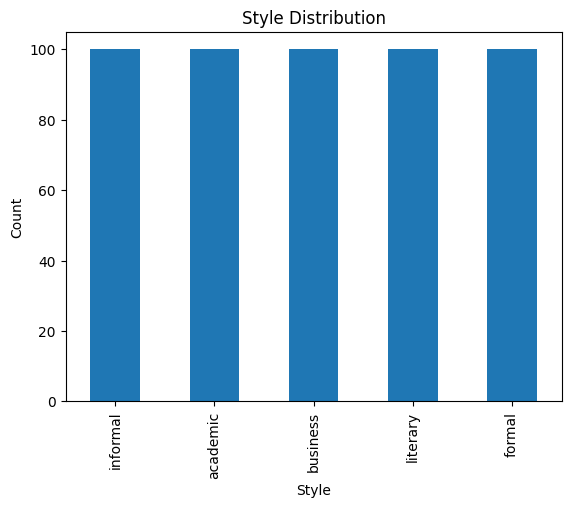

In [5]:
style_counts = df["style"].value_counts()

print(style_counts)

style_counts.plot(kind="bar")

plt.title("Style Distribution")
plt.xlabel("Style")
plt.ylabel("Count")

plt.show()

tone
sarcastic     100
neutral       100
aggressive    100
urgent        100
friendly      100
Name: count, dtype: int64


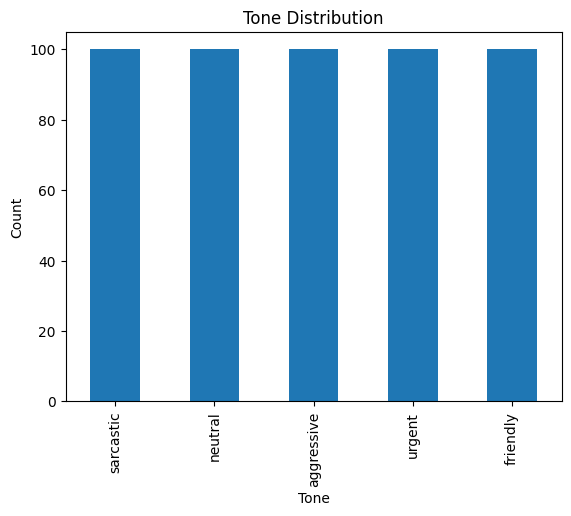

In [6]:
tone_counts = df["tone"].value_counts()

print(tone_counts)

tone_counts.plot(kind="bar")

plt.title("Tone Distribution")
plt.xlabel("Tone")
plt.ylabel("Count")

plt.show()

tone      aggressive  friendly  neutral  sarcastic  urgent
style                                                     
academic          20        20       20         20      20
business          20        20       20         20      20
formal            20        20       20         20      20
informal          20        20       20         20      20
literary          20        20       20         20      20


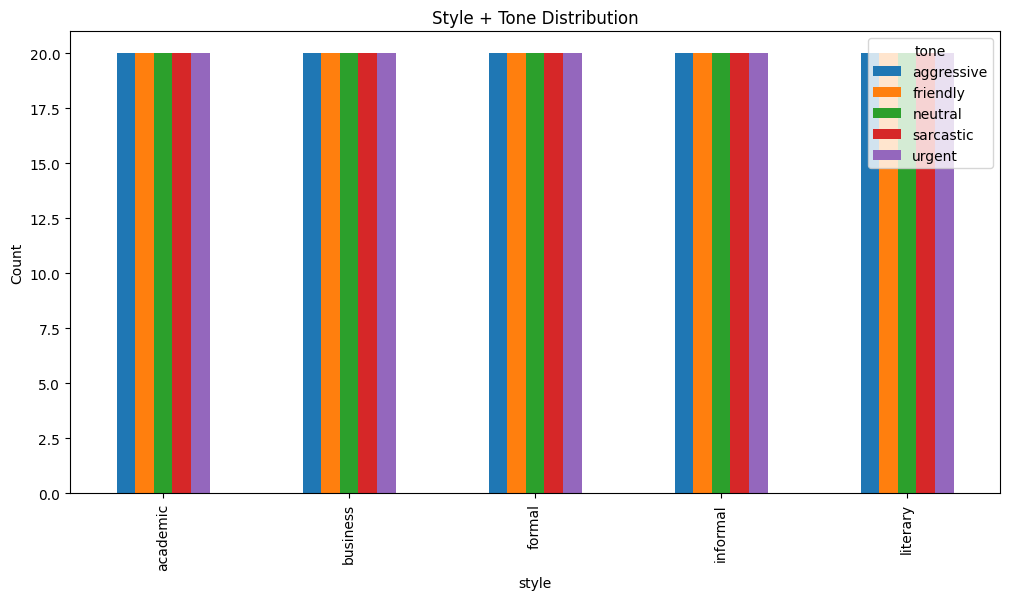

In [7]:
combo_counts = (
    df.groupby(["style", "tone"])
      .size()
      .unstack(fill_value=0)
)

print(combo_counts)

combo_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Style + Tone Distribution")
plt.ylabel("Count")

plt.show()

In [8]:
df["clean_text"] = df["text"].astype(str)
df["text_length"] = df["clean_text"].apply(len)

df["text_length"].describe()

count     500.00000
mean      248.33000
std       253.93151
min         9.00000
25%        93.00000
50%       224.00000
75%       290.00000
max      1334.00000
Name: text_length, dtype: float64

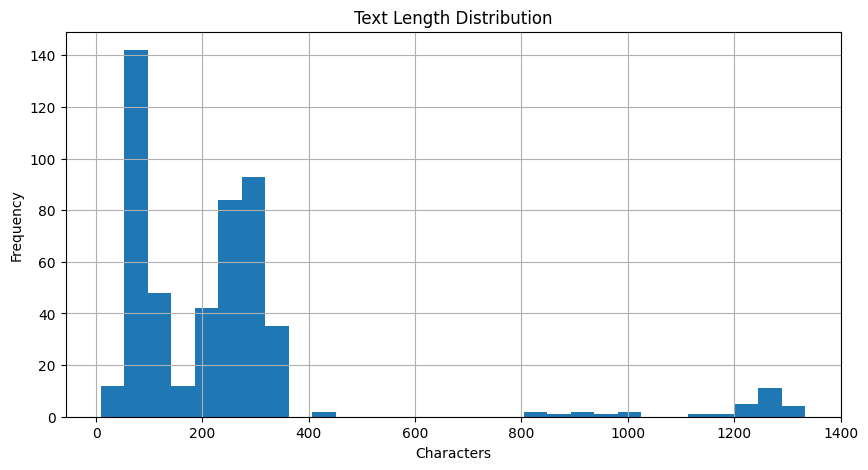

In [9]:
df["text_length"].hist(
    bins=30,
    figsize=(10, 5)
)

plt.title("Text Length Distribution")

plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

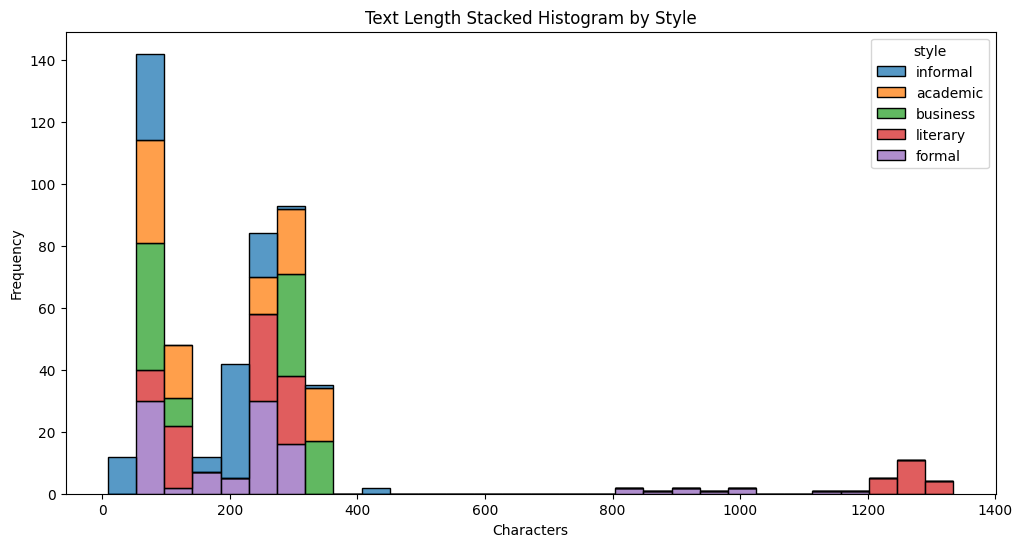

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="style",
    multiple="stack",
    bins=30
)
plt.title("Text Length Stacked Histogram by Style")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

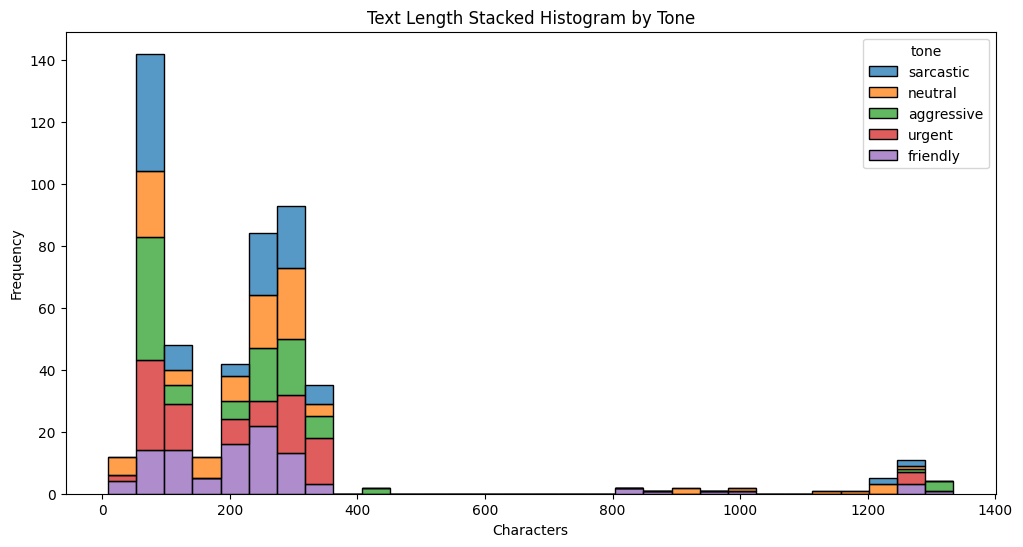

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="tone",
    multiple="stack",
    bins=30
)
plt.title("Text Length Stacked Histogram by Tone")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()